# Stage 1 — Per-modality baselines

Goal: find out what each of the three modalities (tabular, signal, text) is
worth **on its own**, before any fusion. This is the number every later fusion
stage has to beat, and the gap between "best single modality" and "fused"
is the evidence for the brief's central claim that the modalities interact.

Metric: **AUPRC** (average precision), validated with 5-fold
`StratifiedGroupKFold` on `drone_id` so no aircraft's health trajectory leaks
across the train/val split. Floor for a random ranker: ~0.125 (the base rate).


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from scipy.sparse import hstack

from src.data import load_split
from src.cv import get_folds, assert_disjoint_groups
from src.metrics import auprc, report_folds
from src.features_tabular import build_tabular_features
from src.features_signal import build_signal_features
from src.features_text import missing_indicator, tfidf_features, embed_notes

pd.set_option("display.max_columns", 50)
RANDOM_STATE = 42


In [2]:
train = load_split("train")
tab, notes, signals, channel_names = train["tab"], train["notes"], train["signals"], train["channel_names"]
y = tab["failure_within_horizon"].values
print(f"{len(tab)} flights, {tab['drone_id'].nunique()} drones, base rate = {y.mean():.4f}")


15872 flights, 620 drones, base rate = 0.1251


## CV setup

We materialize the fold split **once** here and reuse the exact same
`(train_idx, val_idx)` pairs for every modality below. That's what makes the
three AUPRC numbers comparable to each other later -- they're all scored on
the same held-out drones.


In [3]:
folds = list(get_folds(tab, n_splits=5, seed=RANDOM_STATE))
for i, (tr_idx, val_idx) in enumerate(folds):
    assert_disjoint_groups(tab, tr_idx, val_idx)
    print(f"fold {i}: train={len(tr_idx)} ({y[tr_idx].mean():.3f} pos) "
          f"val={len(val_idx)} ({y[val_idx].mean():.3f} pos)")


fold 0: train=12714 (0.125 pos) val=3158 (0.126 pos)
fold 1: train=12689 (0.125 pos) val=3183 (0.125 pos)
fold 2: train=12676 (0.125 pos) val=3196 (0.124 pos)
fold 3: train=12712 (0.125 pos) val=3160 (0.126 pos)
fold 4: train=12697 (0.125 pos) val=3175 (0.125 pos)


## A. Tabular baseline (LightGBM)

Snapshot columns (airframe config, operating conditions, cumulative usage) +
two layers of engineering:
- **single-flight ratios**: `battery_cycle_rate` (cycles per flight-hour, a
  degradation-rate proxy), `payload_ratio`, `maneuver_rate`.
- **within-drone rolling/trend features** over the last 3 flights
  (`throttle_trend`, `maneuvers_roll_mean`, `payload_roll_std`,
  `battery_cycles_delta`, `flight_hours_delta`). These exist because of the
  label definition: y=1 means "fails in the next 5 flights", so an
  *inflection point* in recent behavior should carry more signal than an
  absolute snapshot.

Categoricals (`model`, `motor_type`, `firmware_version`, `operator_region`)
are passed to LightGBM as native pandas categories, with the **full**
category universe (including airframe model `E`, which has zero training
rows) declared up front -- see `src/data.py::CATEGORY_LEVELS` -- so train and
predict-time category codes stay aligned.


In [4]:
X_tab, cat_cols = build_tabular_features(tab)
feature_cols = [c for c in X_tab.columns if c != "flight_id"]
print(X_tab.shape, "features:", len(feature_cols))
X_tab[feature_cols].head(3)


(15872, 26) features: 25


,battery_capacity_mAh,max_payload_g,propeller_in,manufacture_batch,flight_index,payload_g,ambient_temp_C,wind_speed_ms,flight_duration_min,avg_throttle,num_aggressive_maneuvers,cumulative_flight_hours,battery_cycles,model,motor_type,firmware_version,operator_region,battery_cycle_rate,payload_ratio,maneuver_rate,battery_cycles_delta,flight_hours_delta,throttle_trend,maneuvers_roll_mean,payload_roll_std
0,5200,900.0,11.0,3,1,69.2,18.75,15.63,14.85,0.341,0,16.44,25,C,M3,v3.1,east,1.520681,0.076889,0.000000,0.0,0.00,0.0000,0.0,0.000000
1,5200,900.0,11.0,3,2,728.1,29.90,5.97,10.59,0.762,1,16.61,26,C,M3,v3.1,east,1.565322,0.809000,0.094429,1.0,0.17,0.4210,0.5,465.912658
2,5200,900.0,11.0,3,3,868.3,30.96,12.01,18.62,0.928,2,16.92,27,C,M3,v3.1,east,1.595745,0.964778,0.107411,1.0,0.31,0.2935,1.0,426.686079


In [5]:
lgb_params = dict(
    objective="binary",
    n_estimators=400,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=-1,
)

tab_oof = np.zeros(len(tab))
tab_fold_scores = []
tab_importances = []

for tr_idx, val_idx in folds:
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_tab.loc[tr_idx, feature_cols], y[tr_idx],
        categorical_feature=cat_cols,
    )
    val_pred = model.predict_proba(X_tab.loc[val_idx, feature_cols])[:, 1]
    tab_oof[val_idx] = val_pred
    tab_fold_scores.append(auprc(y[val_idx], val_pred))
    tab_importances.append(model.feature_importances_)

tab_results = report_folds(tab_fold_scores, "Tabular")
tab_oof_auprc = auprc(y, tab_oof)
print(f"Tabular OOF AUPRC (pooled): {tab_oof_auprc:.4f}")


Tabular: fold AUPRCs = [0.2941, 0.2831, 0.2759, 0.3152, 0.2995]
Tabular: mean=0.2936  std=0.0136  (floor~0.125)
Tabular OOF AUPRC (pooled): 0.2897


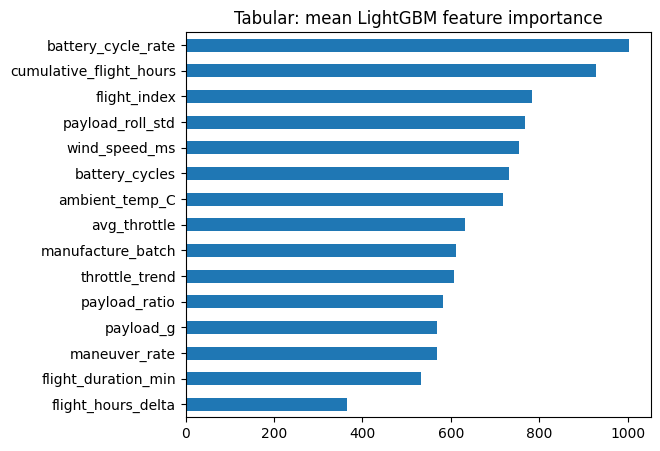

In [6]:
imp = pd.DataFrame(tab_importances, columns=feature_cols).mean().sort_values(ascending=False)
imp.head(15).plot.barh(figsize=(6, 5), title="Tabular: mean LightGBM feature importance").invert_yaxis()


## B. Signal baseline (hand-engineered spectral/statistical features → LightGBM)

Per channel (8 channels): dropout flag + zero-fraction, time-domain stats
(mean/std/skew/kurtosis/min/max/range/slope), and **full-spectrum** features
(3 energy bands rather than one hand-picked band, dominant frequency,
spectral entropy, total power) -- see the module docstring in
`src/features_signal.py` for why a hand-picked "high-frequency = bearing wear"
band turned out to be the wrong prior on this dataset's EDA. Dropout spans are
linearly interpolated from the channel's own clean timesteps before any stat
is computed, so a missing reading doesn't get read as "voltage = 0".


In [7]:
X_sig = build_signal_features(signals, channel_names)
sig_feature_cols = X_sig.columns.tolist()
print(X_sig.shape, "features per flight")
X_sig.filter(like="vibration").head(3)


(15872, 130) features per flight


,vibration_frac_zero,vibration_is_dropout,vibration_mean,vibration_std,vibration_skew,vibration_kurtosis,vibration_min,vibration_max,vibration_range,vibration_slope,vibration_band0_energy,vibration_band1_energy,vibration_band2_energy,vibration_dominant_freq,vibration_spectral_entropy,vibration_total_power
0,0.0,0.0,-0.000540,0.057317,0.027760,0.244374,-0.176287,0.144690,0.320977,-0.000033,2.445035,2.244623,2.245536,15.0,3.432227,3.346857
1,0.0,0.0,0.000336,0.095098,-0.164272,-0.568504,-0.271587,0.199699,0.471286,-0.000578,4.143807,2.091505,1.837817,2.0,1.486468,4.323103
2,0.0,0.0,0.001832,0.113493,0.013032,-1.022931,-0.236369,0.242540,0.478909,-0.000742,4.561460,2.011296,1.698632,2.0,0.986166,4.669671


In [8]:
sig_oof = np.zeros(len(tab))
sig_fold_scores = []

for tr_idx, val_idx in folds:
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_sig.loc[tr_idx, sig_feature_cols], y[tr_idx])
    val_pred = model.predict_proba(X_sig.loc[val_idx, sig_feature_cols])[:, 1]
    sig_oof[val_idx] = val_pred
    sig_fold_scores.append(auprc(y[val_idx], val_pred))

sig_results = report_folds(sig_fold_scores, "Signal")
sig_oof_auprc = auprc(y, sig_oof)
print(f"Signal OOF AUPRC (pooled): {sig_oof_auprc:.4f}")


Signal: fold AUPRCs = [0.2978, 0.274, 0.2803, 0.2839, 0.3001]
Signal: mean=0.2872  std=0.0101  (floor~0.125)
Signal OOF AUPRC (pooled): 0.2840


## C. Text baseline

Two encoders compared:
1. **TF-IDF + logistic regression** -- fit *inside each fold* on that fold's
   training notes only (the vectorizer never sees validation text). With only
   24 unique note templates in the whole dataset this is close to one-hot
   encoding those templates.
2. **Pretrained sentence embeddings** (`BAAI/bge-large-en-v1.5`, frozen, no
   fitting -- so no fold leakage risk) + logistic regression on top. Since
   there are only 24 unique strings in the whole dataset, we embed each
   unique string once and map back, instead of re-encoding the same template
   thousands of times.

Both get a `missing_indicator` feature appended (28% of notes are empty).


In [9]:
note_text = notes["maintenance_note"]
print("unique templates:", note_text.nunique(), "/ rows:", len(note_text))

by_template = tab.assign(note=note_text).groupby("note")["failure_within_horizon"].agg(["mean", "count"])
by_template.sort_values("mean", ascending=False)


unique templates: 24 / rows: 15872


,mean,count
note,,
Inspection flagged bearing wear; recommend motor replacement soon.,0.971429,105
"Maintenance: cell imbalance detected, swap battery pack.",0.968750,64
"Battery health critical, recommend pack replacement.",0.968254,63
"Maintenance: motor bearing degraded, schedule swap.",0.966667,90
"Rotor assembly play exceeds tolerance, replace motor.",0.942529,87
Battery voltage sagged under load near end of flight.,0.432432,111
Noticed faster-than-usual voltage drop during climb.,0.390476,105
Pack felt warm and held charge poorly.,0.363636,88
Faint grinding sound from one rotor under load.,0.336683,199


In [10]:
miss = missing_indicator(note_text).reshape(-1, 1)

tfidf_oof = np.zeros(len(tab))
tfidf_fold_scores = []

for tr_idx, val_idx in folds:
    tr_X, val_X = tfidf_features(note_text.iloc[tr_idx], note_text.iloc[val_idx])
    tr_X = hstack([tr_X, miss[tr_idx]])
    val_X = hstack([val_X, miss[val_idx]])
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(tr_X, y[tr_idx])
    val_pred = clf.predict_proba(val_X)[:, 1]
    tfidf_oof[val_idx] = val_pred
    tfidf_fold_scores.append(auprc(y[val_idx], val_pred))

tfidf_results = report_folds(tfidf_fold_scores, "Text (TF-IDF)")
print(f"TF-IDF OOF AUPRC (pooled): {auprc(y, tfidf_oof):.4f}")


Text (TF-IDF): fold AUPRCs = [0.4394, 0.4106, 0.4207, 0.4178, 0.4261]
Text (TF-IDF): mean=0.4229  std=0.0096  (floor~0.125)
TF-IDF OOF AUPRC (pooled): 0.4405


In [11]:
unique_texts = note_text.unique()
unique_emb = embed_notes(unique_texts.tolist())
emb_lookup = dict(zip(unique_texts, unique_emb))
note_emb = np.vstack(note_text.map(emb_lookup).values)
print("embedding shape:", note_emb.shape, "from", len(unique_texts), "unique templates")

emb_oof = np.zeros(len(tab))
emb_fold_scores = []

for tr_idx, val_idx in folds:
    tr_X = np.hstack([note_emb[tr_idx], miss[tr_idx]])
    val_X = np.hstack([note_emb[val_idx], miss[val_idx]])
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(tr_X, y[tr_idx])
    val_pred = clf.predict_proba(val_X)[:, 1]
    emb_oof[val_idx] = val_pred
    emb_fold_scores.append(auprc(y[val_idx], val_pred))

emb_results = report_folds(emb_fold_scores, "Text (BGE embeddings)")
print(f"BGE-embedding OOF AUPRC (pooled): {auprc(y, emb_oof):.4f}")


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

embedding shape: (15872, 1024) from 24 unique templates
Text (BGE embeddings): fold AUPRCs = [0.4398, 0.4085, 0.4253, 0.4159, 0.4261]
Text (BGE embeddings): mean=0.4231  std=0.0106  (floor~0.125)
BGE-embedding OOF AUPRC (pooled): 0.4409


## Summary: standalone AUPRC by modality

This is the number each fusion stage needs to beat. A meaningful fusion gain
shows up as the fused AUPRC clearing the **best single modality** here, not
just clearing the 0.125 floor.


In [ ]:
summary = pd.DataFrame([
    {"modality": "Tabular", "mean_AUPRC": tab_results["mean"], "std": tab_results["std"], "pooled_OOF_AUPRC": tab_oof_auprc},
    {"modality": "Signal (hand-engineered)", "mean_AUPRC": sig_results["mean"], "std": sig_results["std"], "pooled_OOF_AUPRC": sig_oof_auprc},
    {"modality": "Text (TF-IDF)", "mean_AUPRC": tfidf_results["mean"], "std": tfidf_results["std"], "pooled_OOF_AUPRC": auprc(y, tfidf_oof)},
    {"modality": "Text (BGE embeddings)", "mean_AUPRC": emb_results["mean"], "std": emb_results["std"], "pooled_OOF_AUPRC": auprc(y, emb_oof)},
]).set_index("modality")
summary


,mean_AUPRC,std,pooled_OOF_AUPRC
modality,,,
Tabular,0.293566,0.013593,0.289726
Signal (hand-engineered),0.287236,0.010118,0.283996
Text (TF-IDF),0.422911,0.009633,0.440461
Text (BGE embeddings),0.423133,0.010562,0.440936


In [ ]:
# Persist OOF predictions + fold assignments so the fusion stage (Stage 3) can
# reuse them as stacking inputs without recomputing every baseline.
oof_df = tab[["flight_id", "drone_id", "failure_within_horizon"]].copy()
oof_df["tabular_oof"] = tab_oof
oof_df["signal_oof"] = sig_oof
oof_df["tfidf_oof"] = tfidf_oof
oof_df["text_embed_oof"] = emb_oof
oof_df["fold"] = -1
for i, (_, val_idx) in enumerate(folds):
    oof_df.loc[val_idx, "fold"] = i

Path("../artifacts").mkdir(exist_ok=True)
oof_df.to_csv("../artifacts/stage1_oof_predictions.csv", index=False)
oof_df.head()


,flight_id,drone_id,failure_within_horizon,tabular_oof,signal_oof,tfidf_oof,text_embed_oof,fold
0,0,D1000,0,0.026505,0.014465,0.346459,0.348816,4
1,1,D1000,0,0.017887,0.027867,0.306822,0.311048,4
2,2,D1000,0,0.020436,0.024205,0.306822,0.311048,4
3,3,D1000,0,0.026230,0.035623,0.344209,0.350725,4
4,4,D1000,0,0.026893,0.014820,0.315047,0.313458,4
